# Crystal Lattice - Undamped Springs

<IPython.core.display.Javascript object>

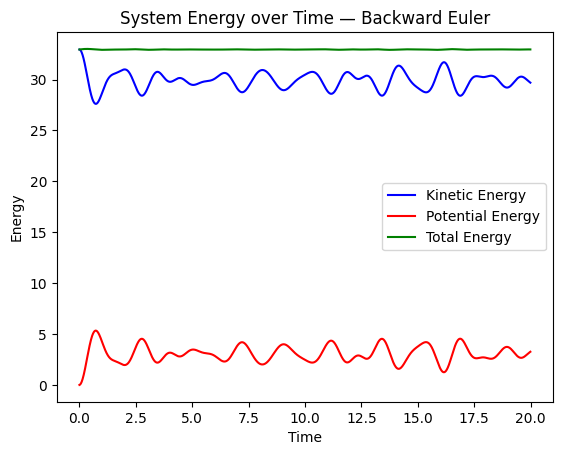

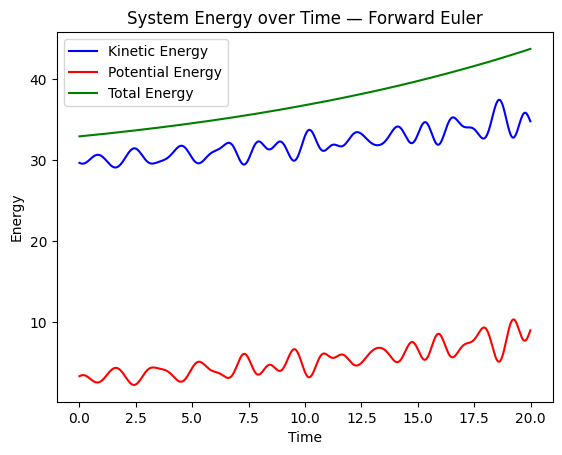

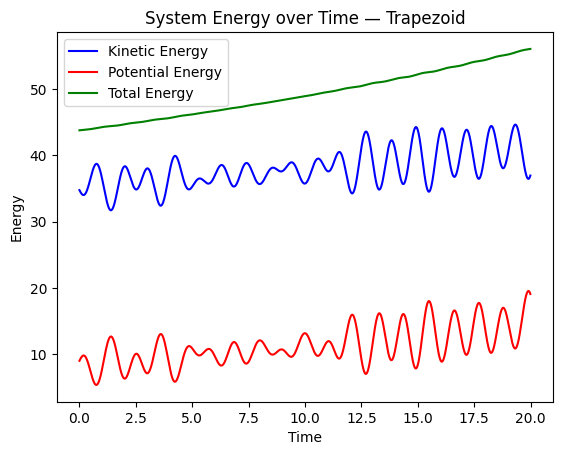

In [6]:
from vpython import *
import random
import matplotlib.pyplot as plt

scene = canvas()
scene.autoscale = False

x0 = 3       # distance between 2 atoms
k = 1        # spring constant
m = 2        # mass of each atom
dt = 0.01
max_steps = 2000

#makes nxnxn molecule structure
grid_size = 3
atoms = []
velocities = []
for i in range(grid_size):
    for j in range(grid_size):
        for l in range(grid_size):
            pos = vec(i * (x0 + 0.5), j * (x0 + 0.5), l * (x0 + 0.5))
            atoms.append(sphere(pos=pos, radius=0.5, color=color.white))
            velocities.append(vec(0, 0, 0))

#add springs between each molecule
spring = []
for a in range(len(atoms)):
    for b in range(a + 1, len(atoms)):
        x0_ab = mag(atoms[b].pos - atoms[a].pos)
        spring.append((a, b, x0_ab))

#initialize random velocities
for d in range(len(atoms)):
    velocities[d] = vec(random.random(), random.random(), random.random())

#calculate forces between each atom
def calc_forces():
    forces = [vec(0, 0, 0) for _ in atoms]
    for a, b, x0_ab in spring:
        x1_vec = atoms[b].pos - atoms[a].pos
        x1 = mag(x1_vec)
        x1_hat = norm(x1_vec)
        X = x1 - x0_ab
        F = -k * X * x1_hat
        forces[a] -= F
        forces[b] += F
    return forces


#integration methods
def backward_euler(forces):  # x(t+dt) = x(t) + v(t+dt)*dt
    for idx in range(len(atoms)):
        a_vec = forces[idx] / m
        velocities[idx] += a_vec * dt
        atoms[idx].pos += velocities[idx] * dt


def forward_euler(forces):  # x(t+dt) = x(t) + v(t)*dt
    for idx in range(len(atoms)):
        a_vec = forces[idx] / m
        atoms[idx].pos += velocities[idx] * dt
        velocities[idx] += a_vec * dt


def trapezoid(forces):  # x(t+dt) = x(t) + 0.5 * [v(t) + v(t+dt)] * dt
    for idx in range(len(atoms)):
        a_vec = forces[idx] / m
        vt = velocities[idx]
        velocities[idx] += a_vec * dt
        atoms[idx].pos += 0.5 * (vt + velocities[idx]) * dt


def calc_KE():
    return sum(0.5 * m * mag(v)**2 for v in velocities)


def calc_PE():
    PE = 0
    for a, b, x0_ab in spring:
        X = mag(atoms[b].pos - atoms[a].pos) - x0_ab
        PE += 0.5 * k * X**2
    return PE


def plot_energies(t_list, ke_list, pe_list, te_list, method):  #method is the integration method used
    
    plt.plot(t_list, ke_list, label='Kinetic Energy',   color='blue')
    plt.plot(t_list, pe_list, label='Potential Energy', color='red')
    plt.plot(t_list, te_list, label='Total Energy',     color='green')
    plt.xlabel('Time')
    plt.ylabel('Energy')
    if method == 1:
        plt.title('System Energy over Time — Backward Euler')
    elif method == 2:
        plt.title('System Energy over Time — Forward Euler')
    else:
        plt.title('System Energy over Time — Trapezoid')
    plt.legend()
    plt.show()


# Main loop

for method, func in [(1, backward_euler), (2, forward_euler), (3, trapezoid)]:
    ke_list, pe_list, te_list, t_list = [], [], [], []
    t = 0
    while t < max_steps * dt:
        rate(100)
        forces = calc_forces()
        func(forces)
        scene.camera.follow(atoms[13]) #always follow middle most ball
        ke_list.append(calc_KE())
        pe_list.append(calc_PE())
        te_list.append(calc_KE() + calc_PE())
        t_list.append(t)
        t += dt
    plot_energies(t_list, ke_list, pe_list, te_list, method)

For initial parameters:
x0 = 3 which is the initial distance between the molecules as it is easiest to calaculate between 3x3x3 square molecule
k = 1 which is spring constant (approximation from the lecture)
dt = 0.01 as I think it is best for visualizing something of this scale
m = 2 which is each atoms mass, used it for simple calculations
rate is 100 for easy visulization on eyes, each initial velocity is randomized, camera is following centermost ball (Atoms[13]).

Visual confirmation:
Without tracking the centermost atom the structure will drift away from the starting point, between all the atoms the attoms move around almost randomly, but retract if the get far from other atoms or drift away if close to other atoms.

Backward Euler Results:
For the backward Euler, total energy is constant, and potential and kinetic energy fluctuate almost in parallel. From a concept standpoint this would make sense as the atoms are all moving because of the other atoms, however I expect it it be less constant as the entire structure moves out to a random vector and doesn't really stand still. 

Comparison of different integration methods:
For dt of 0.01 and max steps being 2000, backward euler had a constant total energy over time while trapezoid and forward euler had an increasing total energy over time with trapezoid being more linear and forward being more curved, By the end of the time step, trapezoid had the most total energy. 
With dt of 0.01 and steps being 1000, the trend is very similar. Trapezoid has most toal energy however get a better look at potential and kinetic energy, trapezoid fluctuates more than the other methods. 
Same dt but steps at 5000, over I noticed that trapezoid although less curvy than forward just has so much more total energy starting at 200 ending up with 600 over time where as forward goesabove 175 but more curvy. Backward is still constant 25. Trapezoid's PE and KE are always crossing streams and go back and forth more than forwards which really only does it at the end.
Dt is now at 0.1 and steps of 2000, all the dt does is increase or decrease the time scale. With this however the trends are the most apparent. Backward is always constant although a little fluctuation. Forward shoots up to 4 (at east for this time step) at around 200 sec mark and trapezoid shoots up to 2.5, but takes a lot more time to get there and does it earlier than Forawrd.
Dt at 0.1 and steps at 200 gives the clearest indication of trends with the most fluctuation however. It is very similar to how the trends are with dt 0.1 and steps 2000 just on a smaller more readable way. 

For smoothness Id suggest 0.01 and 2000 steps, for trends Id suggest 0.1 and 200 steps


# Damped Springs 

<IPython.core.display.Javascript object>

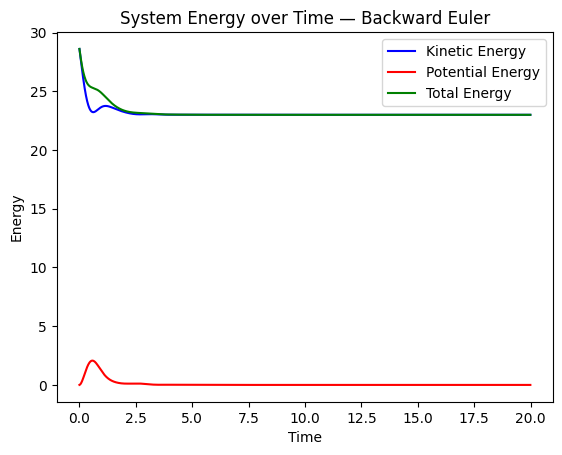

In [2]:
from vpython import *
import random
import matplotlib.pyplot as plt

scene = canvas()
scene.autoscale = False

x0 = 3       # distance between 2 atoms
k = 1        # spring constant
m = 2        # mass of each atom
B = 0.1      #damping coefficient (googled: average damping coeff)
dt = 0.01
max_steps = 2000

#makes nxnxn molecule structure
grid_size = 3
atoms = []
velocities = []
for i in range(grid_size):
    for j in range(grid_size):
        for l in range(grid_size):
            pos = vec(i * (x0 + 0.5), j * (x0 + 0.5), l * (x0 + 0.5))
            atoms.append(sphere(pos=pos, radius=0.5, color=color.white))
            velocities.append(vec(0, 0, 0))

#add springs between each molecule
spring = []
for a in range(len(atoms)):
    for b in range(a + 1, len(atoms)):
        x0_ab = mag(atoms[b].pos - atoms[a].pos)
        spring.append((a, b, x0_ab))

#initialize random velocities
for d in range(len(atoms)):
    velocities[d] = vec(random.random(), random.random(), random.random())

#calculate forces between each atom
def calc_forces():
    forces = [vec(0, 0, 0) for _ in atoms]
    for a, b, x0_ab in spring:
        x1_vec = atoms[b].pos - atoms[a].pos
        x1 = mag(x1_vec)
        x1_hat = norm(x1_vec)
        X = x1 - x0_ab
        F = -k * X * x1_hat - B*(velocities[b] - velocities[a])
        forces[a] -= F
        forces[b] += F
    return forces


#integration methods
def backward_euler(forces):  # x(t+dt) = x(t) + v(t+dt)*dt
    for idx in range(len(atoms)):
        a_vec = forces[idx] / m
        velocities[idx] += a_vec * dt
        atoms[idx].pos += velocities[idx] * dt


def calc_KE():
    return sum(0.5 * m * mag(v)**2 for v in velocities)


def calc_PE():
    PE = 0
    for a, b, x0_ab in spring:
        X = mag(atoms[b].pos - atoms[a].pos) - x0_ab
        PE += 0.5 * k * X**2
    return PE


def plot_energies(t_list, ke_list, pe_list, te_list, method):  #method is the integration method used
    
    plt.plot(t_list, ke_list, label='Kinetic Energy',   color='blue')
    plt.plot(t_list, pe_list, label='Potential Energy', color='red')
    plt.plot(t_list, te_list, label='Total Energy',     color='green')
    plt.xlabel('Time')
    plt.ylabel('Energy')
    if method == 1:
        plt.title('System Energy over Time — Backward Euler')
    elif method == 2:
        plt.title('System Energy over Time — Forward Euler')
    else:
        plt.title('System Energy over Time — Trapezoid')
    plt.legend()
    plt.show()


# Main loop

for method, func in [(1, backward_euler)]:
    ke_list, pe_list, te_list, t_list = [], [], [], []
    t = 0
    while t < max_steps * dt:
        rate(100)
        forces = calc_forces()
        func(forces)
        scene.camera.follow(atoms[13]) #always follow middle most ball
        ke_list.append(calc_KE())
        pe_list.append(calc_PE())
        te_list.append(calc_KE() + calc_PE())
        t_list.append(t)
        t += dt
    plot_energies(t_list, ke_list, pe_list, te_list, method)

Visual Confirmation:
Damping made the springs less unpredictable over time and eventually the springs themselves stopped juggling the atoms until all were static. The molecule kept moving because of the vacuum and no gravity or friction. 

Integration Method:

Damped:

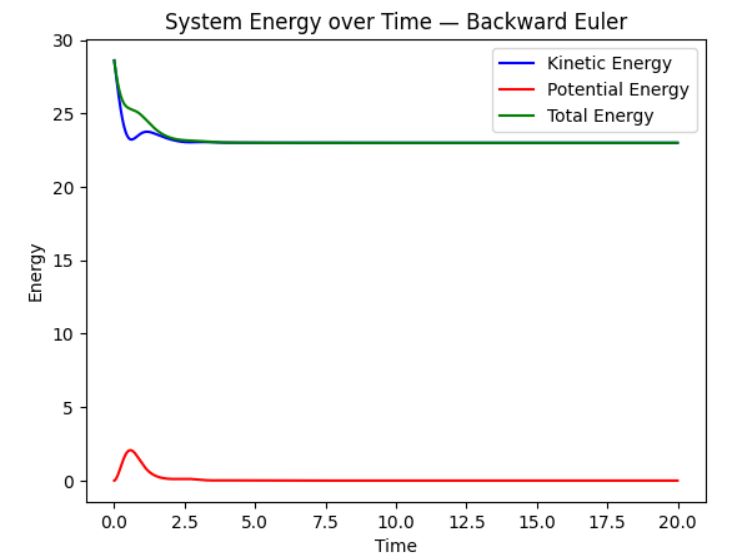

Undamped: 

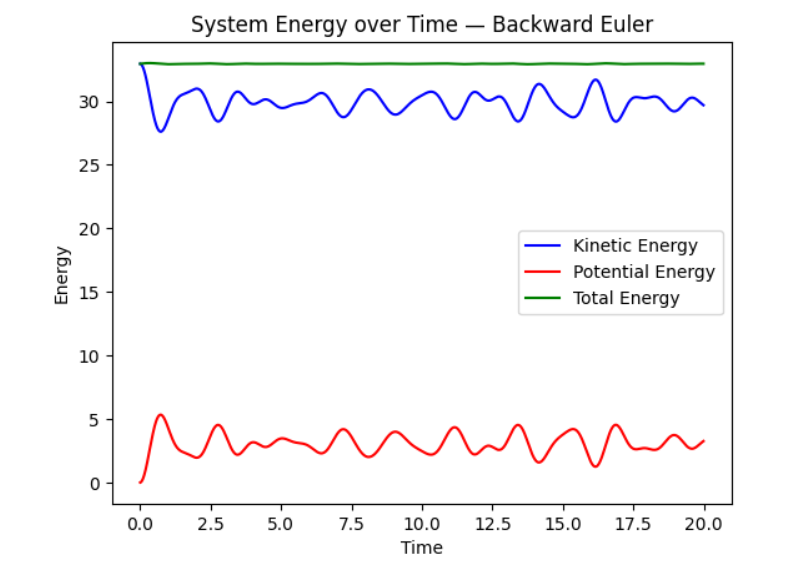

Over Time the Total energy is constant for undamped, but damped decreases the total energy until it is constant Meaning the springs stopped moving. For Damped it also has KE remaining because it was in a Vacuum.